In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    Bidirectional,
    Dense,
    Dropout
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [3]:
train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [5]:
train.tail()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0
159570,fff46fc426af1f9a,"""\nAnd ... I really don't think you understand...",0,0,0,0,0,0


In [6]:
train.duplicated().sum()

np.int64(0)

In [7]:
train.isnull().sum()/train.shape[0]*100

id               0.0
comment_text     0.0
toxic            0.0
severe_toxic     0.0
obscene          0.0
threat           0.0
insult           0.0
identity_hate    0.0
dtype: float64

In [8]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   id             159571 non-null  str  
 1   comment_text   159571 non-null  str  
 2   toxic          159571 non-null  int64
 3   severe_toxic   159571 non-null  int64
 4   obscene        159571 non-null  int64
 5   threat         159571 non-null  int64
 6   insult         159571 non-null  int64
 7   identity_hate  159571 non-null  int64
dtypes: int64(6), str(2)
memory usage: 72.2 MB


In [9]:
test.head()

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


In [10]:
test.tail()

,id,comment_text
153159,fffcd0960ee309b5,". \n i totally agree, this stuff is nothing bu..."
153160,fffd7a9a6eb32c16,== Throw from out field to home plate. == \n\n...
153161,fffda9e8d6fafa9e,""" \n\n == Okinotorishima categories == \n\n I ..."
153162,fffe8f1340a79fc2,""" \n\n == """"One of the founding nations of the..."
153163,ffffce3fb183ee80,""" \n :::Stop already. Your bullshit is not wel..."


In [11]:
test.duplicated().sum()

np.int64(0)

In [12]:
test.isnull().sum()/test.shape[0]*100

id              0.0
comment_text    0.0
dtype: float64

In [13]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 153164 entries, 0 to 153163
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            153164 non-null  str  
 1   comment_text  153164 non-null  str  
dtypes: str(2)
memory usage: 58.6 MB


__Text processing__

In [14]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [15]:
train["comment_text"] = train["comment_text"].apply(clean_text)
test["comment_text"] = test["comment_text"].apply(clean_text)

train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,explanation why the edits made under my userna...,0,0,0,0,0,0
1,000103f0d9cfb60f,daww he matches this background colour im seem...,0,0,0,0,0,0
2,000113f07ec002fd,hey man im really not trying to edit war its j...,0,0,0,0,0,0
3,0001b41b1c6bb37e,more i cant make any real suggestions on impro...,0,0,0,0,0,0
4,0001d958c54c6e35,you sir are my hero any chance you remember wh...,0,0,0,0,0,0


In [16]:
X = train["comment_text"]

y = train[
    [
        "toxic",
        "severe_toxic",
        "obscene",
        "threat",
        "insult",
        "identity_hate"
    ]
]

In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", len(X_train))
print("Validation Samples :", len(X_val))

Training Samples : 127656
Validation Samples : 31915


__Tokenization__

In [18]:
MAX_WORDS = 50000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

__Text to sequence__

In [19]:
X_train_seq = tokenizer.texts_to_sequences(X_train)

X_val_seq = tokenizer.texts_to_sequences(X_val)

__Padding__

In [20]:
MAX_LENGTH = 150

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

__Conversion to tensorflow labels__

In [21]:
y_train = tf.convert_to_tensor(
    y_train.values,
    dtype=tf.float32
)

y_val = tf.convert_to_tensor(
    y_val.values,
    dtype=tf.float32
)

In [22]:
print(type(y_train))
print(type(y_val))

print(y_train.shape)
print(y_val.shape)

<class 'tensorflow.python.framework.ops.EagerTensor'>
<class 'tensorflow.python.framework.ops.EagerTensor'>
(127656, 6)
(31915, 6)


In [23]:
X_train_pad = tf.convert_to_tensor(
    X_train_pad,
    dtype=tf.int32
)

X_val_pad = tf.convert_to_tensor(
    X_val_pad,
    dtype=tf.int32
)

In [24]:
print("Training Shape :", X_train_pad.shape)
print("Validation Shape :", X_val_pad.shape)

print("Training Labels :", y_train.shape)
print("Validation Labels :", y_val.shape)

Training Shape : (127656, 150)
Validation Shape : (31915, 150)
Training Labels : (127656, 6)
Validation Labels : (31915, 6)


__Early stopping__

In [25]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

__LSTM Model__

In [26]:
lstm_model = Sequential([

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
        input_length=MAX_LENGTH
    ),

    LSTM(
        units=64,
        activation="tanh"
    ),

    Dropout(0.5),

    Dense(
        64,
        activation="relu"
    ),

    Dense(
        6,
        activation="sigmoid"
    )

])

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
lstm_model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

In [29]:
history = lstm_model.fit(

    X_train_pad,
    y_train,

    validation_data=(X_val_pad, y_val),

    epochs=5,

    batch_size=128,

    callbacks=[early_stop],

    verbose=1

)

Epoch 1/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 331s 326ms/step - accuracy: 0.9260 - loss: 0.1499 - val_accuracy: 0.9940 - val_loss: 0.1432
Epoch 2/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 276s 276ms/step - accuracy: 0.9932 - loss: 0.1003 - val_accuracy: 0.9941 - val_loss: 0.0799
Epoch 3/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 276s 277ms/step - accuracy: 0.9942 - loss: 0.0657 - val_accuracy: 0.9941 - val_loss: 0.0589
Epoch 4/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 365s 366ms/step - accuracy: 0.9941 - loss: 0.0513 - val_accuracy: 0.9941 - val_loss: 0.0563
Epoch 5/5
998/998 ━━━━━━━━━━━━━━━━━━━━ 295s 296ms/step - accuracy: 0.9938 - loss: 0.0434 - val_accuracy: 0.9941 - val_loss: 0.0523


__Evaluation__

In [30]:
loss, accuracy = lstm_model.evaluate(

    X_val_pad,
    y_val,

    verbose=1

)

print(f"Validation Loss     : {loss:.4f}")
print(f"Validation Accuracy : {accuracy:.4f}")

998/998 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.9941 - loss: 0.0523
Validation Loss     : 0.0523
Validation Accuracy : 0.9941


__Accuracy Plot__

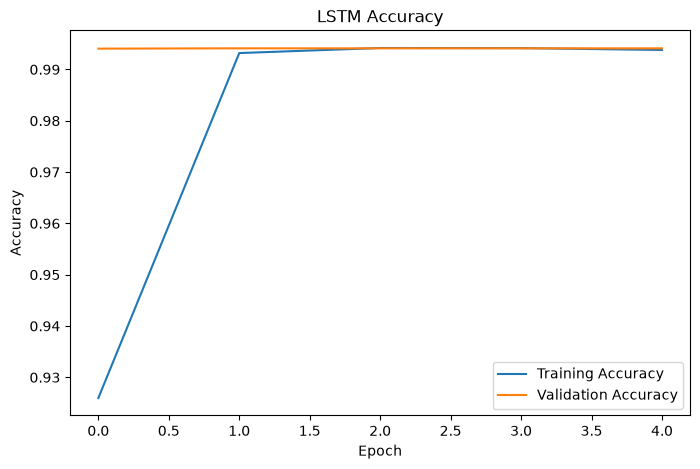

In [31]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("LSTM Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

__Loss plot__

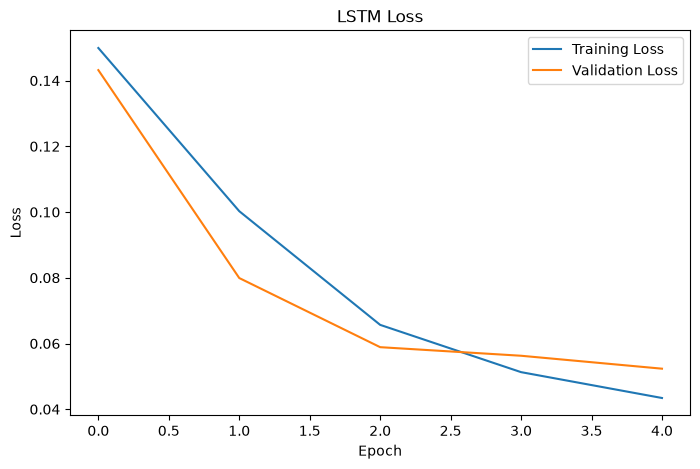

In [32]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

__Model and Tokenizer saving__

In [33]:
lstm_model.save("toxicity_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [34]:
import pickle

with open("tokenizer.pkl","wb") as f:
    pickle.dump(tokenizer,f)

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


__Test prediction__

In [35]:
labels = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

In [36]:
sample = [
    "I hate you idiot"
]

sample = [clean_text(x) for x in sample]

sample_seq = tokenizer.texts_to_sequences(sample)

sample_pad = pad_sequences(

    sample_seq,

    maxlen=MAX_LENGTH,

    padding="post",

    truncating="post"

)

prediction = lstm_model.predict(sample_pad)

prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


array([[0.98826647, 0.24832584, 0.90966207, 0.05496919, 0.7776239 ,
        0.16701487]], dtype=float32)

In [37]:
for label, score in zip(labels, prediction[0]):
    print(f"{label:15}: {score:.4f}")

toxic          : 0.9883
severe_toxic   : 0.2483
obscene        : 0.9097
threat         : 0.0550
insult         : 0.7776
identity_hate  : 0.1670
